<a href="https://colab.research.google.com/github/samanta-muskan/PRODIGY_ML_01/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("train.csv")

print(df.head())

Saving train.csv to train.csv
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  Sal

In [3]:

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (1460, 81)

Column names:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

In [4]:

# Create a total bathroom feature
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

# Select input features
X = df[["GrLivArea", "BedroomAbvGr", "TotalBathrooms"]]

# Select target variable
y = df["SalePrice"]

print(X.head())
print(y.head())

   GrLivArea  BedroomAbvGr  TotalBathrooms
0       1710             3             3.5
1       1262             3             2.5
2       1786             3             3.5
3       1717             3             2.0
4       2198             4             3.5
0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64


In [5]:

print(X.isnull().sum())
print(y.isnull().sum())

# Remove rows with missing selected values
data = pd.concat([X, y], axis=1).dropna()

X = data[["GrLivArea", "BedroomAbvGr", "TotalBathrooms"]]
y = data["SalePrice"]

print("Final dataset shape:", X.shape)

GrLivArea         0
BedroomAbvGr      0
TotalBathrooms    0
dtype: int64
0
Final dataset shape: (1460, 3)


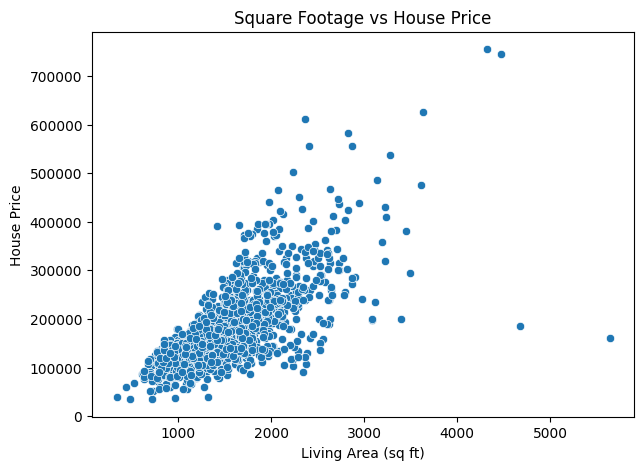

In [6]:

plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Square Footage vs House Price")
plt.xlabel("Living Area (sq ft)")
plt.ylabel("House Price")
plt.show()

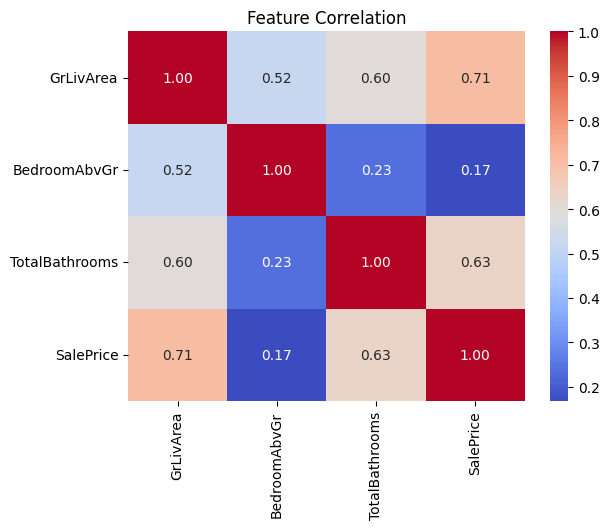

In [7]:

sns.heatmap(
    data[["GrLivArea", "BedroomAbvGr",
          "TotalBathrooms", "SalePrice"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.show()

In [8]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 3)
Testing data: (292, 3)


In [9]:

model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [10]:

y_pred = model.predict(X_test)

print("Predicted prices:")
print(y_pred[:10])

print("\nActual prices:")
print(y_test.head(10).values)

Predicted prices:
[113611.53310361 321075.73322926 117980.40627361 185120.41397544
 234377.60269572 133726.4522589  212573.04502953 180519.24185596
 133726.4522589  144377.41273318]

Actual prices:
[154500 325000 115000 159000 315500  75500 311500 146000  84500 135500]


In [11]:

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 34395.802888482795
Mean Squared Error: 2623753007.3513374
Root Mean Squared Error: 51222.58298203379
R2 Score: 0.6579346254018674


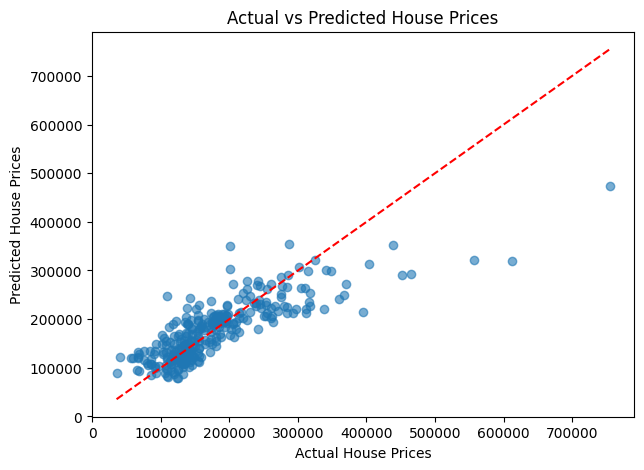

In [12]:

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Perfect prediction reference line
min_price = min(y_test.min(), y_pred.min())
max_price = max(y_test.max(), y_pred.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    "r--"
)

plt.show()

In [13]:

# Example house
new_house = pd.DataFrame({
    "GrLivArea": [2000],
    "BedroomAbvGr": [3],
    "TotalBathrooms": [2.5]
})

predicted_price = model.predict(new_house)

print(
    "Predicted House Price: $",
    round(predicted_price[0], 2)
)

Predicted House Price: $ 232016.59


In [14]:

print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 36976.44834025696
GrLivArea : 94.66424501407216
BedroomAbvGr : -23244.43381400451
TotalBathrooms : 30177.981686892424


In [15]:

import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [16]:

from google.colab import files

files.download("house_price_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:

from google.colab import files
import pandas as pd
from sklearn.linear_model import LinearRegression

# Upload Kaggle test.csv
uploaded_test = files.upload()

# Read the uploaded file
test_filename = next(iter(uploaded_test))
test_df = pd.read_csv(test_filename)

print("Uploaded file:", test_filename)
print("Test dataset shape:", test_df.shape)

# Handle missing basement bathroom values
test_df["BsmtFullBath"] = test_df["BsmtFullBath"].fillna(0)
test_df["BsmtHalfBath"] = test_df["BsmtHalfBath"].fillna(0)

# Calculate total bathrooms
test_df["TotalBathrooms"] = (
    test_df["FullBath"]
    + 0.5 * test_df["HalfBath"]
    + test_df["BsmtFullBath"]
    + 0.5 * test_df["BsmtHalfBath"]
)

# Select features
X_kaggle = test_df[
    ["GrLivArea", "BedroomAbvGr", "TotalBathrooms"]
]

# Handle remaining missing values using training medians
X_kaggle = X_kaggle.fillna(X.median())

# Train the final model using the training dataset
final_model = LinearRegression()
final_model.fit(X, y)

# Predict house prices
test_predictions = final_model.predict(X_kaggle)

# Create submission file
submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": test_predictions
})

# Save predictions
submission.to_csv("submission.csv", index=False)

print(submission.head())
print("Predictions completed successfully!")

Saving train.csv to train (1).csv
Uploaded file: train (1).csv
Test dataset shape: (1460, 81)
   Id      SalePrice
0   1  235812.971418
1   2  161110.308994
2   3  243397.918828
3   4  191524.494773
4   5  260604.255122
Predictions completed successfully!


In [21]:

import pandas as pd

# Enter details of a new house
new_house = pd.DataFrame({
    "GrLivArea": [2500],       # Square footage
    "BedroomAbvGr": [4],       # Number of bedrooms
    "TotalBathrooms": [3]    # Number of bathrooms
})

# Predict the house price
predicted_price = model.predict(new_house)

# Display the result
print("House Details:")
print("Square Footage: 2500 sq ft")
print("Bedrooms: 4")
print("Bathrooms: 3")

print("\nPredicted House Price: $",
      round(predicted_price[0], 2))

House Details:
Square Footage: 2500 sq ft
Bedrooms: 4
Bathrooms: 3

Predicted House Price: $ 271193.27
